In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
os.chdir('/home/jovyan/kuratov/data/test_time_gd/')

import torch

from transformers import GPT2Config, GPT2LMHeadModel

from kv_dataset_utils import create_tokenizer

from grad_memgpt import GradMemGPT

In [2]:
import json
from pathlib import Path

checkpoint = 'checkpoint-5000'
exp_path = Path('/home/jovyan/kuratov/data/test_time_gd/runs/N0-S1(4-4)_1M/gradmemgpt_L4H4D128_mem8_K5_ilr1.0_grad_second_bs_64_lr_1e-04/run_1/')
# checkpoint = 'checkpoint-1500'
# exp_path = Path('/home/jovyan/kuratov/data/test_time_gd/runs/N0-S1(4-4)_1M/gradmemgpt_L4H4D128_mem8_K1_ilr1.0_grad_second_bs_64_lr_1e-04/run_1')

exp_config = exp_path / 'config.json'
exp_config = json.load(open(exp_config))['cli_args']

exp_config

{'exp_path': './runs/N0-S1(4-4)_1M/gradmemgpt_L4H4D128_mem8_K5_ilr1.0_grad_second_bs_64_lr_1e-04/run_1',
 'per_device_batch_size': 64,
 'data_path': './data/N0-S1(4-4)_1M',
 'gradient_accumulation_steps': 1,
 'total_batch_size': 64,
 'metric_for_best_model': 'token_accuracy',
 'warmup_steps': 1000,
 'max_steps': 200000,
 'logging_steps': 250,
 'eval_steps': 250,
 'weight_decay': 0.0,
 'learning_rate': 0.0001,
 'lr_scheduler_type': 'constant_with_warmup',
 'early_stopping_patience': 500,
 'seed': 143,
 'n_layer': 4,
 'n_head': 4,
 'n_embd': 128,
 'n_mem_tokens': 8,
 'K': 5,
 'inner_lr': 1.0,
 'use_adam': False,
 'grad_mode': 'second'}

In [3]:
# create tokenizer
tokenizer = create_tokenizer()

# create model config
config = GPT2Config.from_pretrained('gpt2')
config.n_layer = exp_config['n_layer']
config.n_head = exp_config['n_head']
config.n_embd = exp_config['n_embd']
config.vocab_size = 128
config.pad_token_id = tokenizer.convert_tokens_to_ids('[PAD]')
config.bos_token_id = tokenizer.convert_tokens_to_ids('[BOS]')
config.eos_token_id = tokenizer.convert_tokens_to_ids('[EOS]')

# Create gradmemgpt model
model = GradMemGPT(config, n_mem_tokens=exp_config['n_mem_tokens'], K=exp_config['K'], lr=exp_config['inner_lr'],
                   use_adam=exp_config['use_adam'], grad_mode=exp_config['grad_mode'])

In [4]:
from safetensors.torch import load_model

load_model(model, exp_path / checkpoint / 'model.safetensors')
model.eval()
model.cuda()

GradMemGPT(
  (gpt): GPT2LMHeadModel(
    (transformer): GPT2Model(
      (wte): Embedding(128, 128)
      (wpe): Embedding(1024, 128)
      (drop): Dropout(p=0.1, inplace=False)
      (h): ModuleList(
        (0-3): 4 x GPT2Block(
          (ln_1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (attn): GPT2Attention(
            (c_attn): Conv1D(nf=384, nx=128)
            (c_proj): Conv1D(nf=128, nx=128)
            (attn_dropout): Dropout(p=0.1, inplace=False)
            (resid_dropout): Dropout(p=0.1, inplace=False)
          )
          (ln_2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (mlp): GPT2MLP(
            (c_fc): Conv1D(nf=512, nx=128)
            (c_proj): Conv1D(nf=128, nx=512)
            (act): NewGELUActivation()
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
      )
      (ln_f): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    )
    (lm_head): Linear(in_features=128, out_features=128, bias=

In [5]:
with torch.no_grad():
    print(model.mem)

Parameter containing:
tensor([[-0.0084, -0.0116, -0.0046,  ...,  0.0036,  0.0033,  0.0010],
        [ 0.0124,  0.0099, -0.0122,  ..., -0.0088,  0.0054,  0.0045],
        [ 0.0014, -0.0221, -0.0076,  ...,  0.0080, -0.0013,  0.0119],
        ...,
        [ 0.0053, -0.0031, -0.0008,  ...,  0.0145, -0.0095,  0.0051],
        [-0.0098,  0.0115, -0.0100,  ...,  0.0056,  0.0123,  0.0156],
        [-0.0053,  0.0289, -0.0198,  ..., -0.0061, -0.0126, -0.0001]],
       device='cuda:0', requires_grad=True)


In [6]:
import datasets
dataset = datasets.load_from_disk('./data/N0-S1(4-4)_1M')['valid']
dataset[0]

{'context': 'PlvI|', 'query': '?!:', 'target': 'PlvI|'}

In [7]:
from torch.utils.data import DataLoader

def collate_fn(batch, tokenizer):
    context = [item['context'] for item in batch]
    query = [item['query'] + item['target'] for item in batch]

    context_input_ids = tokenizer(context, return_tensors="pt", add_special_tokens=False,
                                  padding=True, pad_to_multiple_of=8).input_ids
    query_input_ids = tokenizer(query, return_tensors="pt", add_special_tokens=False,
                                padding=True, pad_to_multiple_of=8).input_ids
    # add labels_mask
    # input_seq: 0, target_seq: 1, seq = input_seq + target_seq
    labels_mask = torch.zeros_like(query_input_ids)
    for i, item in enumerate(batch):
        query_seq_len = len(item['query'])
        target_seq_len = len(item['target'])
        labels_mask[i, query_seq_len:query_seq_len+target_seq_len] = 1

    labels = query_input_ids * labels_mask + (1 - labels_mask) * -100
    return {
        # 'context_input_ids': context_input_ids,
        # 'query_input_ids': query_input_ids,
        'input_ids': {
            'context_input_ids': context_input_ids,
            'query_input_ids': query_input_ids,
        },
        'labels': labels,
    }

def data_collator(batch):
    return collate_fn(batch, tokenizer)

dataloader = DataLoader(dataset, batch_size=1, collate_fn=data_collator, shuffle=True)

for batch in dataloader:
    print(batch)
    break

{'input_ids': {'context_input_ids': tensor([[50, 36, 59, 55, 69,  0,  0,  0]]), 'query_input_ids': tensor([[67, 66, 68, 50, 36, 59, 55, 69]])}, 'labels': tensor([[-100, -100, -100,   50,   36,   59,   55,   69]])}


In [8]:
from safetensors.torch import load_model

load_model(model, exp_path / checkpoint / 'model.safetensors')
model.eval()
model.cuda()
init_mem = model.mem.data.clone().detach()
init_lr = model.lr
model.lr = exp_config['inner_lr'] / exp_config['total_batch_size']
print(model.lr)

0.015625


In [9]:
import numpy as np
from tqdm import tqdm

ignore_token_ids = [tokenizer.convert_tokens_to_ids(t) for t in ['!', '|']]

cl_steps = 50

# Initialize lists to store metrics for each step across runs
accuracies = [[] for _ in range(cl_steps)]
exact_matches = [[] for _ in range(cl_steps)]

N = 100
for run in tqdm(range(100)):

    load_model(model, exp_path / checkpoint / 'model.safetensors')
    model.eval()
    model.cuda()
    init_mem = model.mem.data.clone().detach()
    init_lr = model.lr
    model.lr = exp_config['inner_lr'] / exp_config['total_batch_size']

    cl_step = 0
    for batch in dataloader:
        with torch.no_grad():
            if cl_step >= cl_steps:
                break

            # print(f'cl_step: {cl_step}')
            batch['input_ids']['context_input_ids'] = batch['input_ids']['context_input_ids'].to('cuda')
            batch['input_ids']['query_input_ids'] = batch['input_ids']['query_input_ids'].to('cuda')
            batch['labels'] = batch['labels'].to('cuda')

            outputs = model(**batch, return_mem=True)
            loss = outputs['loss']
            logits = outputs['predictions']

            logits = logits[..., :-1, :]
            labels = batch['labels'][..., 1:]
            preds = torch.argmax(logits, axis=-1)

            mask = (labels != -100)
            for t_id in ignore_token_ids:
                mask &= (labels != t_id)

            masked_predictions = preds[mask]
            masked_labels = labels[mask]

            accuracy = (masked_predictions == masked_labels).to(torch.float32).mean()

            exact_match = torch.mean(torch.tensor([
                torch.all(pred[mask[i]] == lab[mask[i]]).item()
                for i, (pred, lab) in enumerate(zip(preds, labels))
                if torch.any(mask[i]).item()  # Skip samples that are all masked
            ], dtype=torch.float32))

            # Store metrics for this step
            accuracies[cl_step] += [accuracy.item()]
            exact_matches[cl_step] += [exact_match.item()]

            inp_c = batch['input_ids']['context_input_ids'][0]
            inp_q = batch['input_ids']['query_input_ids'][0]
            label = labels[0]
            mask = (label != -100)
            inp_c[inp_c == -100] = 0
            inp_q[inp_q == -100] = 0
            label[label == -100] = 0

            pred = preds[0][mask]

            # print('i:', tokenizer.decode(torch.cat([inp_c, inp_q]), skip_special_tokens=True).replace(' ', ''))
            # p = tokenizer.decode(pred, skip_special_tokens=True).replace(' ', '')
            # t = tokenizer.decode(label, skip_special_tokens=True).replace(' ', '')
            # print('p:', p)
            # print('t:', t)

            # print(f'loss: {loss:.4f}, inner_loss: {outputs["inner_loss"]:.4f}, token_acc: {accuracy:.2f}, exact_match: {exact_match:.2f}')
            # print('-' * 100)
            
            model.mem.data = outputs['mem'][0].clone().detach()
            # model.mem.data = init_mem.clone().detach()
            cl_step += 1


accuracies = np.array(accuracies)
exact_matches = np.array(exact_matches)

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [04:34<00:00,  2.74s/it]


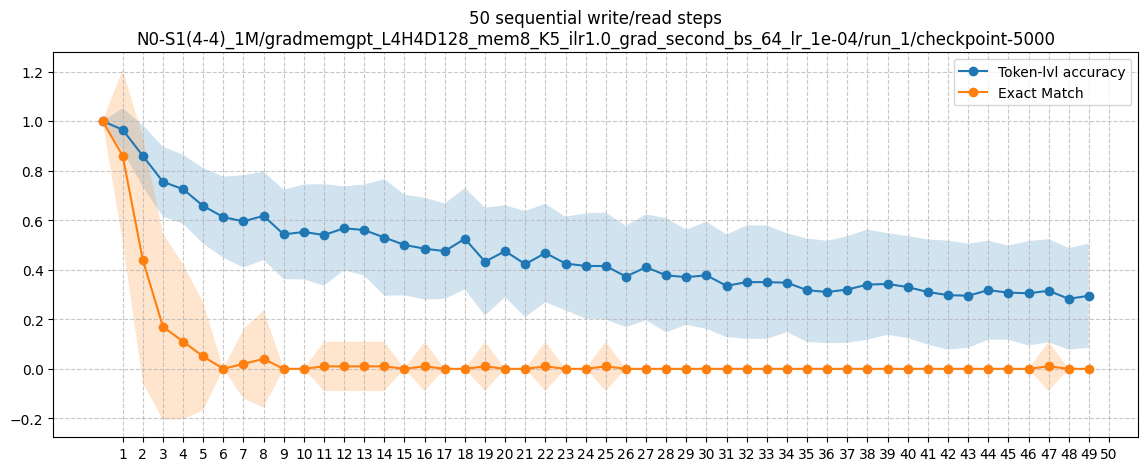

In [10]:
# plot accuracies, exact_matches
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 5))

# Calculate means and standard deviations
acc_mean = accuracies.mean(axis=1)
acc_std = accuracies.std(axis=1)
exact_mean = exact_matches.mean(axis=1)
exact_std = exact_matches.std(axis=1)

# Plot means with shaded standard deviation regions
plt.plot(acc_mean, label='Token-lvl accuracy', marker='o')
plt.fill_between(range(len(acc_mean)), 
                 acc_mean - acc_std, 
                 acc_mean + acc_std, 
                 alpha=0.2)

plt.plot(exact_mean, label='Exact Match', marker='o')
plt.fill_between(range(len(exact_mean)), 
                 exact_mean - exact_std, 
                 exact_mean + exact_std, 
                 alpha=0.2)

# Add grid and show all x-axis values
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(1,len(acc_mean)+1))  # Show all x-axis values

plt.title(f'{cl_steps} sequential write/read steps\n'
    f'{exp_path.relative_to(exp_path.parents[2])/checkpoint}')
plt.legend()
plt.show()
